Equazione della parabola (calcolata escludendo y=0): y = 0.006x^2 + -1.264x + 52.265

Valori previsti dal modello:
x = 0.0 -> y = 52.26
x = 1.0 -> y = 51.01
x = 2.0 -> y = 49.76
x = 3.0 -> y = 48.52
x = 4.0 -> y = 47.30
x = 5.0 -> y = 46.08
x = 6.0 -> y = 44.88
x = 7.0 -> y = 43.69
x = 8.0 -> y = 42.51
x = 9.0 -> y = 41.34
x = 10.0 -> y = 40.18
x = 11.0 -> y = 39.04
x = 12.0 -> y = 37.90
x = 13.0 -> y = 36.78
x = 14.0 -> y = 35.66
x = 15.0 -> y = 34.56
x = 16.0 -> y = 33.47
x = 17.0 -> y = 32.39
x = 18.0 -> y = 31.32
x = 19.0 -> y = 30.26
x = 20.0 -> y = 29.22
x = 21.0 -> y = 28.18
x = 22.0 -> y = 27.16
x = 23.0 -> y = 26.14
x = 24.0 -> y = 25.14
x = 25.0 -> y = 24.15
x = 26.0 -> y = 23.17
x = 27.0 -> y = 22.20
x = 28.0 -> y = 21.24
x = 29.0 -> y = 20.30
x = 30.0 -> y = 19.36
x = 31.0 -> y = 18.44
x = 32.0 -> y = 17.53
x = 33.0 -> y = 16.62
x = 34.0 -> y = 15.73
x = 35.0 -> y = 14.85
x = 36.0 -> y = 13.99
x = 37.0 -> y = 13.13
x = 38.0 -> y = 12.28
x = 39.0 -> y = 11.45
x = 40.0 -> y =

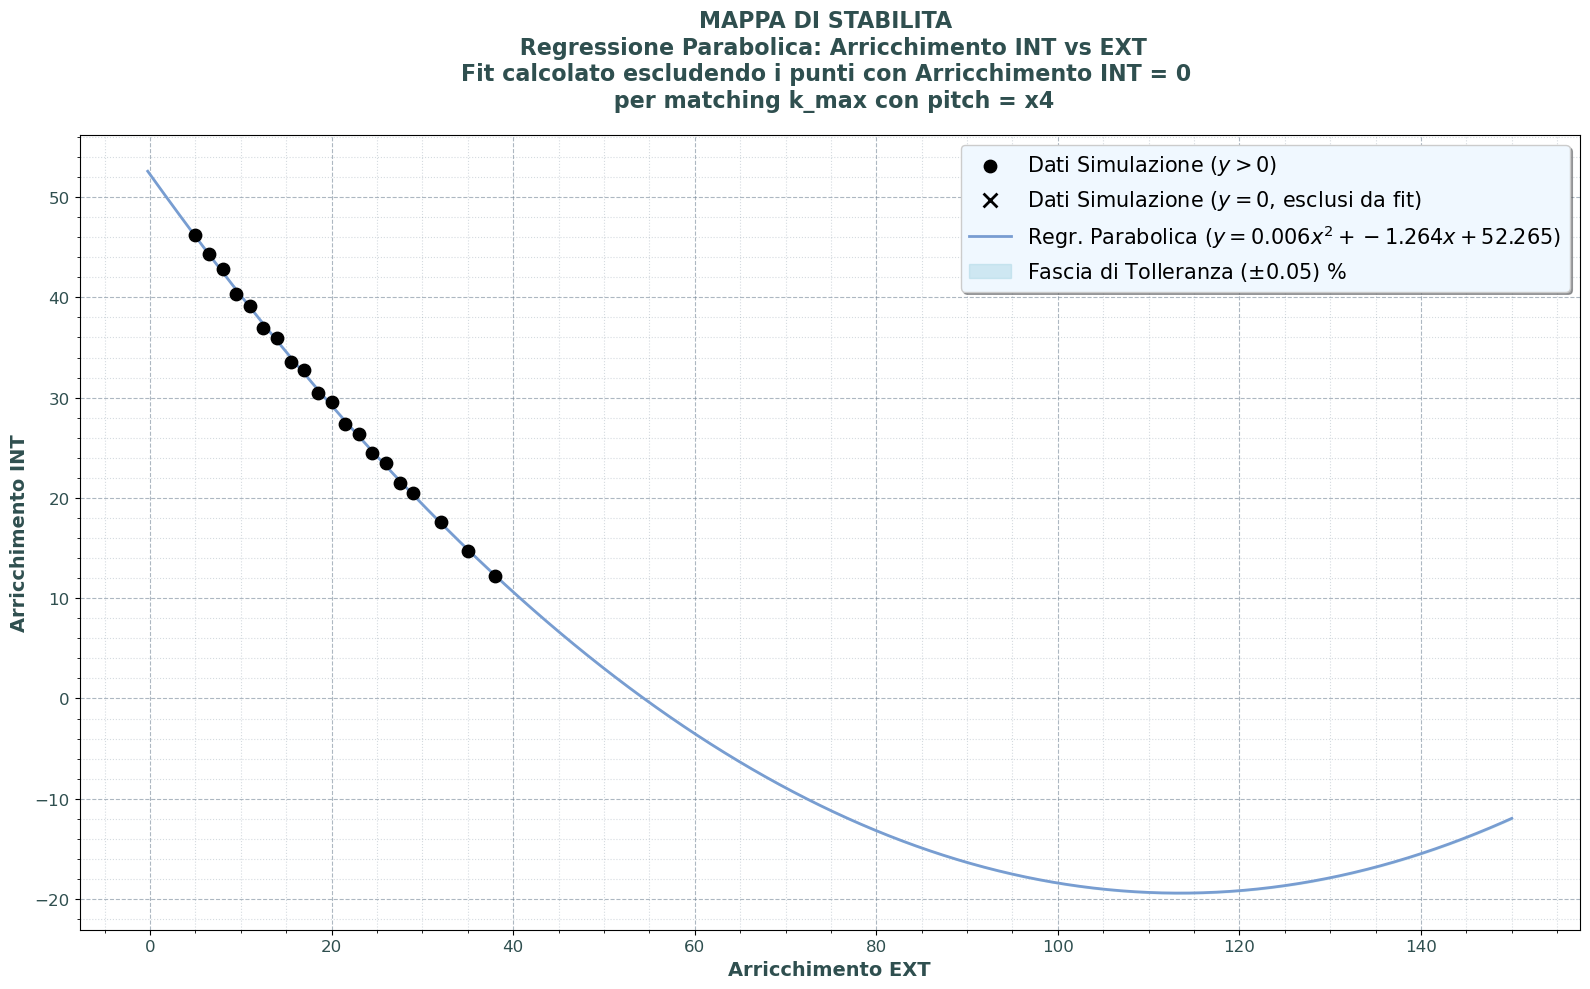

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analizza_e_plotta(file_path):
    """
    Legge i dati di simulazione, esegue regressione parabolica ESCLUDENDO i punti con y=0,
    e genera il plot differenziando i marcatori per y=0.
    """
    # Definizione manuale delle colonne
    nomi_colonne = [
        'Pres', 'moltiplicatore', 'PERC_water', 'Arricch_MAX',
        'Arricch_min', 'T_WATER', 'T_FUEL', 'K_max', 'std_k_max',
        'K_auto', 'std_k_auto', 'Compatibilità'
    ]
    
    # Lettura del file
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=3, names=nomi_colonne, engine='python')
    
    # Estrazione array completi per la visualizzazione
    x_tutti = df['Arricch_min'].values
    y_tutti = df['Arricch_MAX'].values

    # --- MODIFICA 1: Filtro dei dati per la regressione ---
    # Creiamo maschere booleane per separare i dati validi (y > 0) da quelli nulli (y = 0)
    maschera_validi = y_tutti > 0
    maschera_zeri = y_tutti == 0

    x_validi = x_tutti[maschera_validi]
    y_validi = y_tutti[maschera_validi]

    x_zeri = x_tutti[maschera_zeri]
    y_zeri = y_tutti[maschera_zeri]

    # --- MODIFICA 2: Regressione solo sui dati validi ---
    # Calcolo regressione parabolica (polinomio di grado 2) usando SOLO x_validi, y_validi
    a, b, c = np.polyfit(x_validi, y_validi, 2)

    # Vettori per l'estrapolazione del modello (x da 1 a 20)
    x_pred = np.arange(0, 50)
    y_pred = a * x_pred**2 + b * x_pred + c

    # Output analitico a terminale (ora basato sul nuovo modello)
    print(f"Equazione della parabola (calcolata escludendo y=0): y = {a:.3f}x^2 + {b:.3f}x + {c:.3f}\n")
    print("Valori previsti dal modello:")
    for x, y in zip(x_pred, y_pred):
        y_visualizzato = y
        print(f"x = {x:2.1f} -> y = {y_visualizzato:.2f}")

    # Configurazione della Figura
    fig, ax = plt.subplots(figsize=(16, 10))

    # --- MODIFICA 3: Plot differenziato dei dati di simulazione ---
    # 3a. Plot dei dati validi (pallini neri)
    ax.scatter(x_validi, y_validi, color='#000000', s=80, zorder=5, label='Dati Simulazione ($y>0$)')
    
    # 3b. Plot dei dati con y=0 (X nera)
    ax.scatter(x_zeri, y_zeri, color='#000000', marker='x', s=100, linewidth=2, zorder=5, label='Dati Simulazione ($y=0$, esclusi da fit)')

    # Plot della curva di regressione
    x_full = np.linspace(-0.25, 150, 500) # Usiamo più punti per una curva morbida
    y_full = a * x_full**2 + b * x_full + c
    ax.plot(x_full, y_full, color='#789DD1', linestyle='-', linewidth=2, zorder=4, 
            label=f'Regr. Parabolica ($y={a:.3f}x^2+{b:.3f}x+{c:.3f}$)')

    # --- MODIFICA 4: Plot differenziato dei valori estrapolati ---
    # Maschere per i valori previsti
    maschera_pred_validi = y_pred > 0
    maschera_pred_zeri = y_pred <= 0 # Consideriamo zeri anche i valori leggermente negativi del modello

    # Formattazione Titolo e Assi
    ax.set_title('MAPPA DI STABILITA \n Regressione Parabolica: Arricchimento INT vs EXT\nFit calcolato escludendo i punti con Arricchimento INT = 0 \n per matching k_max con pitch = x4', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento EXT', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento INT', fontsize=14, fontweight='bold', color='#2F4F4F')

    # Limiti assi per coerenza
    #ax.set_xlim(-1, 21)
    #ax.set_ylim(-1, 20)

    # Formattazione Tick
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')

    offset = 0.05     # 50 PCM
    y_upper = y_full + offset
    y_lower = y_full - offset

    ax.fill_between(x_full, y_lower, y_upper, color='#ADD8E6', alpha=0.5, zorder=3,
                    label=f'Fascia di Tolleranza ($\pm{offset}$) %')

    # Setup della griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Setup Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=15, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.savefig('regressione_parabolica_filtrata.png', dpi=300)
    plt.show()

    return a, b, c

a, b, c = analizza_e_plotta('../result_final.txt')


### --- Analisi Rette --- ###

Retta 0 [P_i(1, 46.21) -> P_f(11, 5.00)]: Media = 25.607

Retta 1 [P_i(1, 44.32) -> P_f(11, 6.50)]: Media = 25.409

Retta 2 [P_i(1, 40.34) -> P_f(11, 9.50)]: Media = 24.920

Retta 3 [P_i(1, 36.91) -> P_f(11, 12.50)]: Media = 24.704

Retta 4 [P_i(1, 33.56) -> P_f(11, 15.50)]: Media = 24.532

Retta 5 [P_i(1, 30.49) -> P_f(11, 18.50)]: Media = 24.496

Retta 6 [P_i(1, 27.36) -> P_f(11, 21.50)]: Media = 24.430

Retta 7 [P_i(1, 24.50) -> P_f(11, 24.50)]: Media = 24.497

Retta 8 [P_i(1, 21.50) -> P_f(11, 27.50)]: Media = 24.501

Retta 9 [P_i(1, 42.84) -> P_f(11, 8.00)]: Media = 25.417

Retta 10 [P_i(1, 39.15) -> P_f(11, 11.00)]: Media = 25.075

Retta 11 [P_i(1, 35.95) -> P_f(11, 14.00)]: Media = 24.974

Retta 12 [P_i(1, 32.73) -> P_f(11, 17.00)]: Media = 24.867

Retta 13 [P_i(1, 29.56) -> P_f(11, 20.00)]: Media = 24.778

Retta 14 [P_i(1, 26.38) -> P_f(11, 23.00)]: Media = 24.691

Retta 15 [P_i(1, 23.52) -> P_f(11, 26.00)]: Media = 24.759

Retta 16 [P_i(1, 20.52)

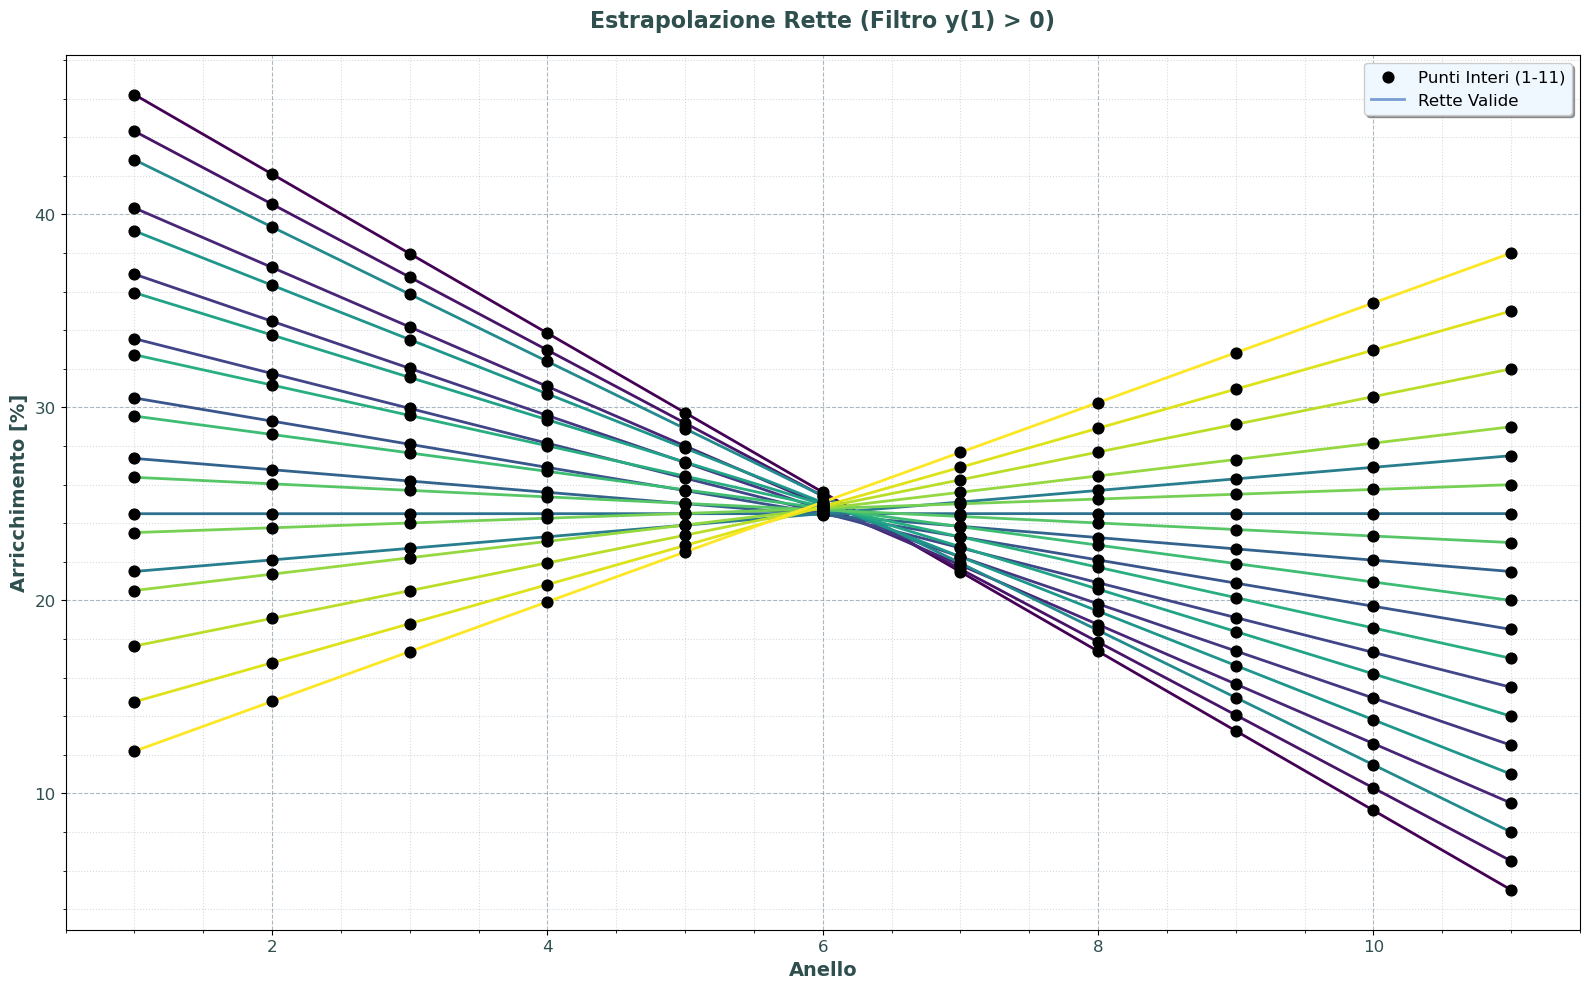

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_rette_filtrate(x_pred, y_pred):
    """
    Traccia rette da (1, y_pred) a (11, x_pred) escludendo quelle 
    con arricchimento iniziale (Anello 1) pari a zero.
    """
    print("### --- Analisi Rette --- ###\n")
    
    fig, ax = plt.subplots(figsize=(16, 10))
    media_vect = []
    x_discrete = np.arange(1, 12)
    
    # Colormap per le rette valide
    colors = cm.viridis(np.linspace(0, 1, len(x_pred)))
    
    for i, (x_p, y_p) in enumerate(zip(x_pred, y_pred)):
        y_start = y_p
        y_end = x_p
        
        # FILTRO: Se l'arricchimento all'anello 1 è 0, salta questa retta
        if y_start == 0:
            continue
            
        # Calcolo coefficienti retta: y = m*x + q
        m = (y_end - y_start) / 10.0
        q = y_start - m * 1.0
        
        # Valutazione sui punti discreti 1-11
        y_discrete = m * x_discrete + q
        media_y = np.mean(y_discrete)
        
        print(f"Retta {i} [P_i(1, {y_start:.2f}) -> P_f(11, {y_end:.2f})]: Media = {media_y:.3f}\n")
        media_vect.append(media_y)
        
        # Plot della retta e dei punti
        ax.plot(x_discrete, y_discrete, color=colors[i], linestyle='-', linewidth=2, zorder=4)
        ax.scatter(x_discrete, y_discrete, color='#000000', s=60, zorder=5)

    # Formattazione grafica standard richiesto
    ax.set_title('Estrapolazione Rette (Filtro y(1) > 0)', fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Anello', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.scatter([], [], color='#000000', s=60, label='Punti Interi (1-11)')
    ax.plot([], [], color='#789DD1', linestyle='-', linewidth=2, label='Rette Valide')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.show()
    
    return np.array(media_vect)

# Definizione dei dati basata sul tuo file analisi.ipynb
import numpy as np

# Percorso del file specificato
file_path = '../result_final.txt'

# Caricamento del dataset. 
data = np.genfromtxt(file_path, skip_header=3)

# Creazione del vettore x_pred estraendo la colonna di interesse
x_pred = data[:, 4]
y_pred = data[:, 3]
# Verifica dell'output
#print(x_pred)
#y_pred = a * x_pred**2 + b * x_pred + c

res = plot_rette_filtrate(x_pred, y_pred)

Se scrivi un breve script per calcolare questa sommatoria per ogni coppia di $(a_{int}, a_{ext})$ che hai verificato nel test di circolarità, il risultato non sarà matematicamente identico fino all'ultimo decimale, ma seguirà una fisica ben precisa.L'Ordine di Grandezza: Il valore della sommatoria rimarrà per lo più costante, dimostrando che stai analizzando core con lo stesso inventario di fissile.La Variazione Fina (Importanza Neutronica): Noterai una leggera discrepanza sistematica. Quando metti l'arricchimento maggiore al centro, la sommatoria totale (massa totale) necessaria per ottenere il $k_{max}$ sarà leggermente inferiore rispetto a quando sposti l'arricchimento in periferia.Questo avviene perché il flusso termico $\phi$ è massimo al centro del nocciolo. Un atomo di $U^{235}$ posizionato al centro ha un'importanza spaziale maggiore rispetto a uno al bordo. Quindi, per eguagliare la reattività, ti serve meno massa totale se la concentri al centro, e più massa totale se la spargi verso l'esterno dove i neutroni sfuggono (leakage).


Ecco l'analisi scientifica del risultato:La Tendenza: La pendenza è chiaramente positiva. Man mano che aumenti l'arricchimento periferico (EXT) e svuoti il centro, la massa totale proporzionale di U-235 necessaria per mantenere l'autovalore bersaglio $k_{max}$ aumenta.La Fisica (Leakage e Importanza): Al centro del reattore, il flusso neutronico $\phi$ è massimo. Un atomo fissile lì posizionato ha una probabilità nettamente maggiore di intercettare un neutrone termico e generare fissione rispetto allo stesso atomo posizionato sull'anello esterno.La "Tassa di Fuga": Spostando il materiale verso l'esterno (dove l'arricchimento EXT cresce), le fissioni avvengono in prossimità del confine del moderatore, aumentando vertiginosamente la probabilità di leakage (fuga dei neutroni dal sistema). Per compensare questa inefficienza spaziale e ottenere lo stesso bilancio globale, il tuo algoritmo è stato costretto ad immettere più massa totale.La Scala del Fenomeno: Osserva attentamente l'asse Y. Il valore oscilla da $\sim 20.245$ a $\sim 20.295$. Stiamo parlando di una deviazione relativa dello 0.25%. È una fluttuazione microscopica: ecco perché nel grafico di circolarità precedente i valori di $k$ sembravano formare una linea piatta perfetta. Al primo ordine la massa è invariante, al secondo ordine paghi l'efficienza spaziale.Hai matematicamente quantificato la "penalità" neutronica legata all'appiattimento radiale del nocciolo.


### --- Analisi Massa Proporzionale U-235 --- ###

Configurazione EXT=5.0, INT=46.21 -> Massa Proporzionale: 9110.31
Configurazione EXT=6.5, INT=44.32 -> Massa Proporzionale: 9242.81
Configurazione EXT=9.5, INT=40.34 -> Massa Proporzionale: 9477.60
Configurazione EXT=12.5, INT=36.91 -> Massa Proporzionale: 9802.32
Configurazione EXT=15.5, INT=33.56 -> Massa Proporzionale: 10141.72
Configurazione EXT=18.5, INT=30.49 -> Massa Proporzionale: 10525.68
Configurazione EXT=21.5, INT=27.36 -> Massa Proporzionale: 10900.06
Configurazione EXT=24.5, INT=24.50 -> Massa Proporzionale: 11318.18
Configurazione EXT=27.5, INT=21.50 -> Massa Proporzionale: 11715.33
Configurazione EXT=8.0, INT=42.84 -> Massa Proporzionale: 9443.77
Configurazione EXT=11.0, INT=39.15 -> Massa Proporzionale: 9726.58
Configurazione EXT=14.0, INT=35.95 -> Massa Proporzionale: 10089.42
Configurazione EXT=17.0, INT=32.73 -> Massa Proporzionale: 10450.11
Configurazione EXT=20.0, INT=29.56 -> Massa Proporzionale: 10816.74
Config

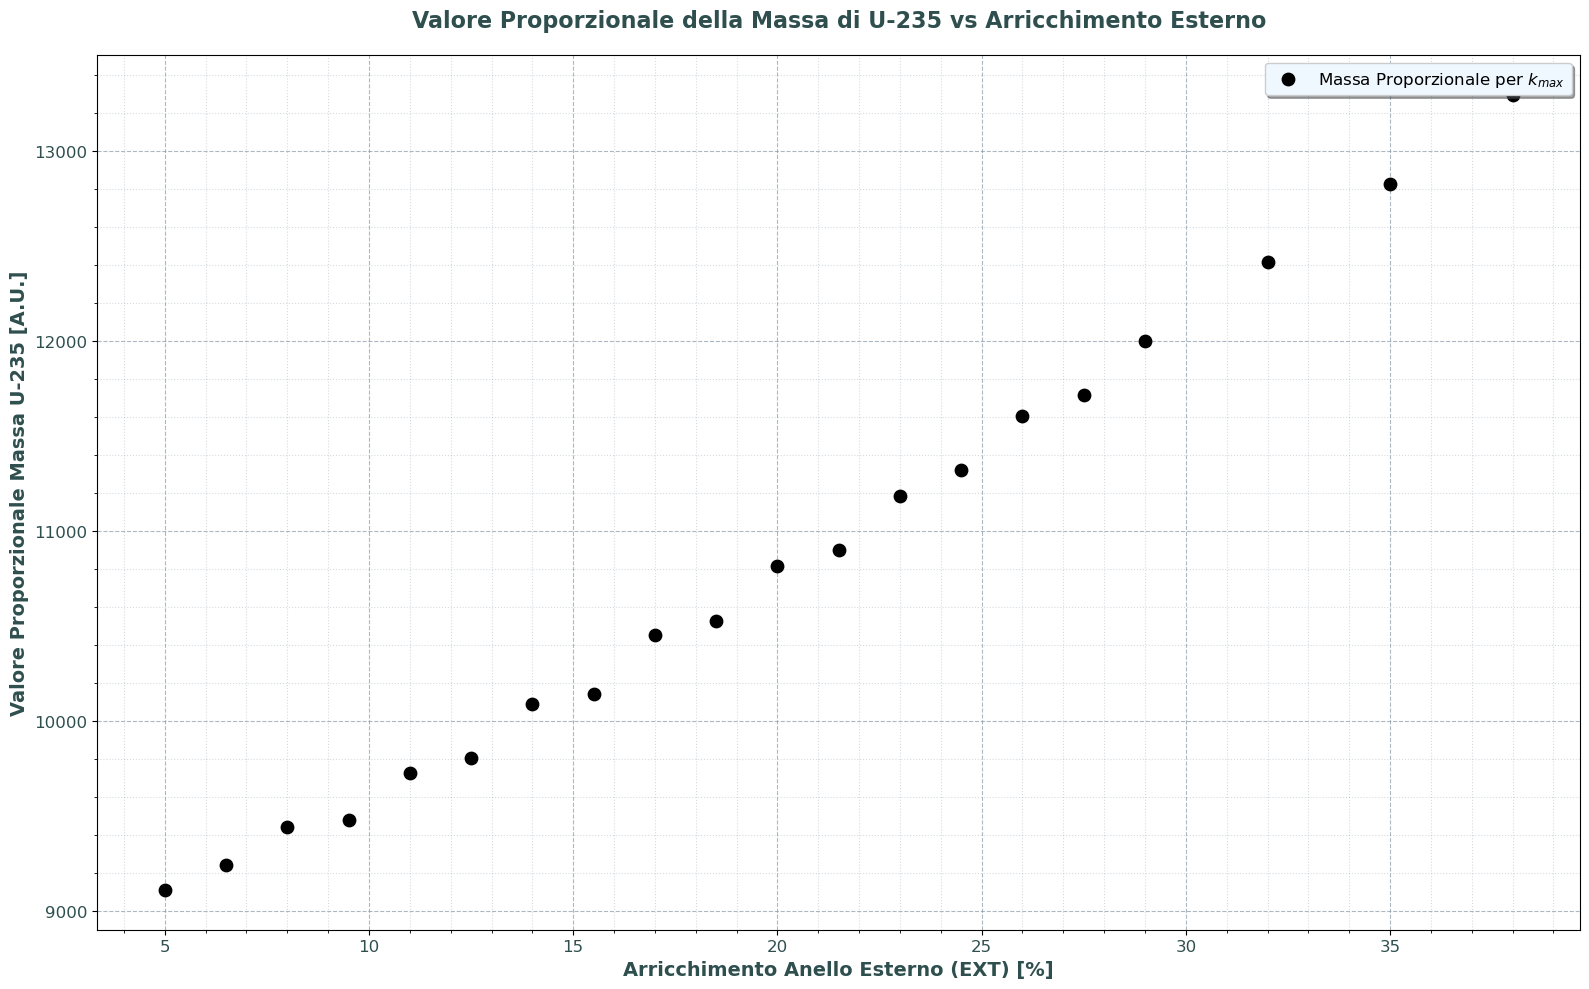

In [13]:
def calcola_e_plotta_massa(x_pred, y_pred):
    """
    Calcola il valore proporzionale alla massa di U235 per le diverse configurazioni 
    e ne esegue il plot, filtrando i valori con arricchimento INT iniziale non positivo.
    """
    print("\n### --- Analisi Massa Proporzionale U-235 --- ###\n")
    
    # Definizione geometria anelli
    anelli = np.arange(1, 12)
    n_barre = 6 * (anelli + 1)
    
    valid_x = []
    mass_vect = []
    
    for i, (x_p, y_p) in enumerate(zip(x_pred, y_pred)):
        y_start = y_p
        y_end = x_p
        
        # Filtro: escludiamo le configurazioni con arricchimento iniziale nullo/negativo
        if y_start <= 0:
            continue
            
        # Calcolo coefficienti retta: e_n = m * n + q
        m = (y_end - y_start) / 10.0
        q = y_start - m * 1.0
        
        # Arricchimenti valutati sui punti discreti 1-11
        arricchimenti = m * anelli + q
        
        # Integrale discreto della massa: Somma(N_barre * arricchimento_n)
        massa_prop = np.sum(n_barre * arricchimenti)
        
        valid_x.append(x_p)
        mass_vect.append(massa_prop)
        print(f"Configurazione EXT={x_p:2.1f}, INT={y_start:5.2f} -> Massa Proporzionale: {massa_prop:.2f}")

    # Plot
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Linea di tendenza (Interpolazione)
    #ax.plot(valid_x, mass_vect, color='#789DD1', linestyle='-', linewidth=2, zorder=4, label='Deriva di Massa')
    
    # Punti sperimentali valutati
    ax.scatter(valid_x, mass_vect, color='#000000', s=80, zorder=5, label='Massa Proporzionale per $k_{max}$')
    
    # Formattazione assi e titolo
    ax.set_title('Valore Proporzionale della Massa di U-235 vs Arricchimento Esterno', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento Anello Esterno (EXT) [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Valore Proporzionale Massa U-235 [A.U.]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Setup della griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
    
    plt.tight_layout()
    plt.savefig('deriva_massa_u235.png', dpi=300)
    plt.show()
    
    return np.array(valid_x), np.array(mass_vect)

# Chiamata della funzione usando i vettori elaborati dal tuo blocco precedente
x_val, massa_val = calcola_e_plotta_massa(x_pred, y_pred)

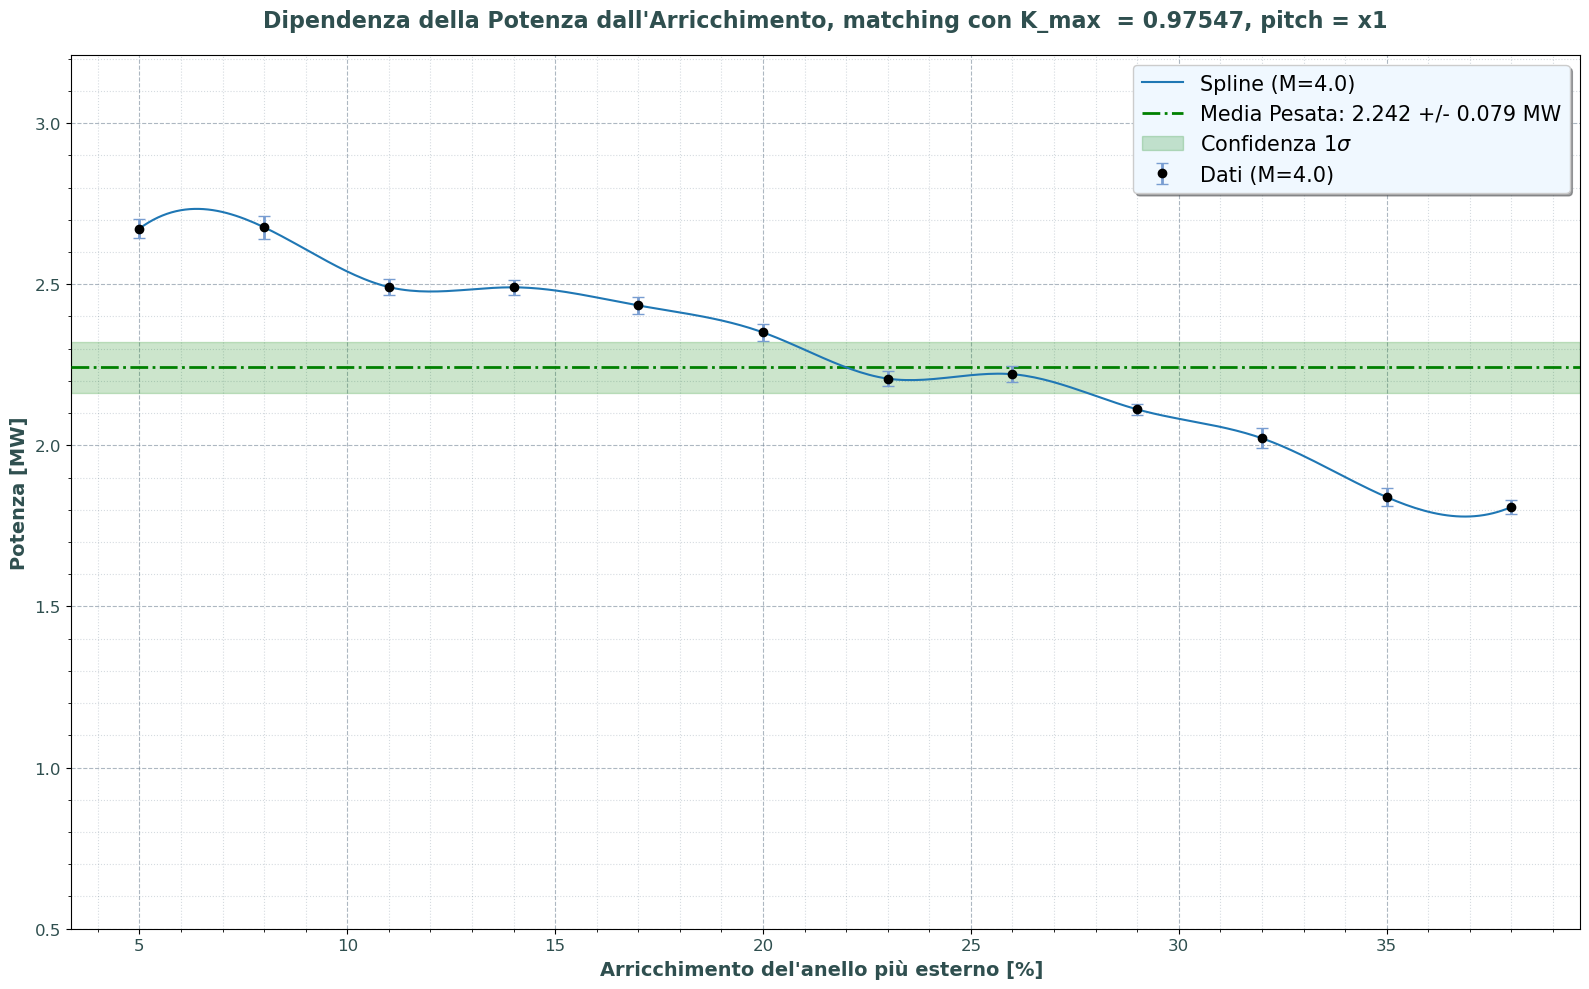

In [14]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import openmc

E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                   # Fotoni/s dal sincrotrone

def analizza_potenza():
    """Legge i file .h5, estrae media e deviazione standard delle fissioni, calcola potenza e incertezza."""
    file_list = glob.glob("../fixed/statepoints/statepoint_arr_ext_*.h5")
    
    if not file_list:
        print("Nessun file statepoint trovato nella cartella corrente.")
        return pd.DataFrame()
        
    dati = []
    pattern = re.compile(r"statepoint_arr_ext_(\d+)_pitch_([\d\.]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        moltiplicatore = float(match.group(2))
        arricchimento = float(match.group(1)) 
        
        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0] # Estrazione errore statistico
            except KeyError:
                print(f"Attenzione: Tally 'fission_tot' non trovato in {file_sp}")
                continue
                
        # Calcolo Potenza e Incertezza [MW]
        potenza_MW = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        errore_MW = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        dati.append({
            'Arricchimento': arricchimento,
            'Moltiplicatore': moltiplicatore,
            'Potenza_MW': potenza_MW,
            'Errore_MW': errore_MW
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Genera plot a dispersione con barre di errore, interpolazione spline, media pesata e banda di confidenza."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    moltiplicatori = df['Moltiplicatore'].unique()
    
    for m in moltiplicatori:
        df_m = df[df['Moltiplicatore'] == m].sort_values(by='Arricchimento')
        
        x = df_m['Arricchimento'].values
        y = df_m['Potenza_MW'].values
        y_err = df_m['Errore_MW'].values
        
        # Plot dei punti centrali con barre di errore (styling rigoroso)
        ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                    elinewidth=2, capsize=4, zorder=5, label=f'Dati (M={m})')
        
        # Interpolazione morbida
        if len(x) >= 3:
            x_smooth = np.linspace(x.min(), x.max(), 300)
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            ax.plot(x_smooth, y_smooth, zorder=4, label=f'Spline (M={m})')
        else:
            ax.plot(x, y, zorder=4, label=f'Line (M={m})')

    # Calcolo rigoroso media pesata su tutto il dataset
    pesi = 1.0 / (df['Errore_MW']**2)
    media_pesata = np.sum(df['Potenza_MW'] * pesi) / np.sum(pesi)

    chi_quadro = np.sum(((df['Potenza_MW'] - media_pesata)**2) / (df['Errore_MW']**2))
    chi_ridotto = chi_quadro / (len(df) - 1)
    errore_media = 1.0 / np.sqrt(np.sum(pesi))

    # Se chi_ridotto > 1, i dati variano più dell'errore statistico
    errore_media = errore_media * np.sqrt(max(1, chi_ridotto))
    
    # Aggiunta retta orizzontale verde e banda di confidenza
    ax.axhline(y=media_pesata, color='green', linestyle='-.', linewidth=2, 
               zorder=3, label=f'Media Pesata: {media_pesata:.3f} +/- {errore_media:.3f} MW')
    ax.axhspan(ymin=media_pesata - errore_media, ymax=media_pesata + errore_media, 
               color='green', alpha=0.2, zorder=2, label=r'Confidenza $1\sigma$')
            
    # Formattazione
    ax.set_title('Dipendenza della Potenza dall\'Arricchimento, matching con K_max  = 0.97547, pitch = x1', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento del\'anello più esterno [%] ', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    # Griglia avanzata
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda
    ax.legend(loc='upper right', frameon=True, shadow=True, 
              fontsize=15, facecolor='#F0F8FF')

    plt.ylim(0.5, df['Potenza_MW'].max() * 1.2)
    
    plt.tight_layout()
    plt.savefig('scatter_potenza_errore.png', dpi=300)
    plt.show()

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)

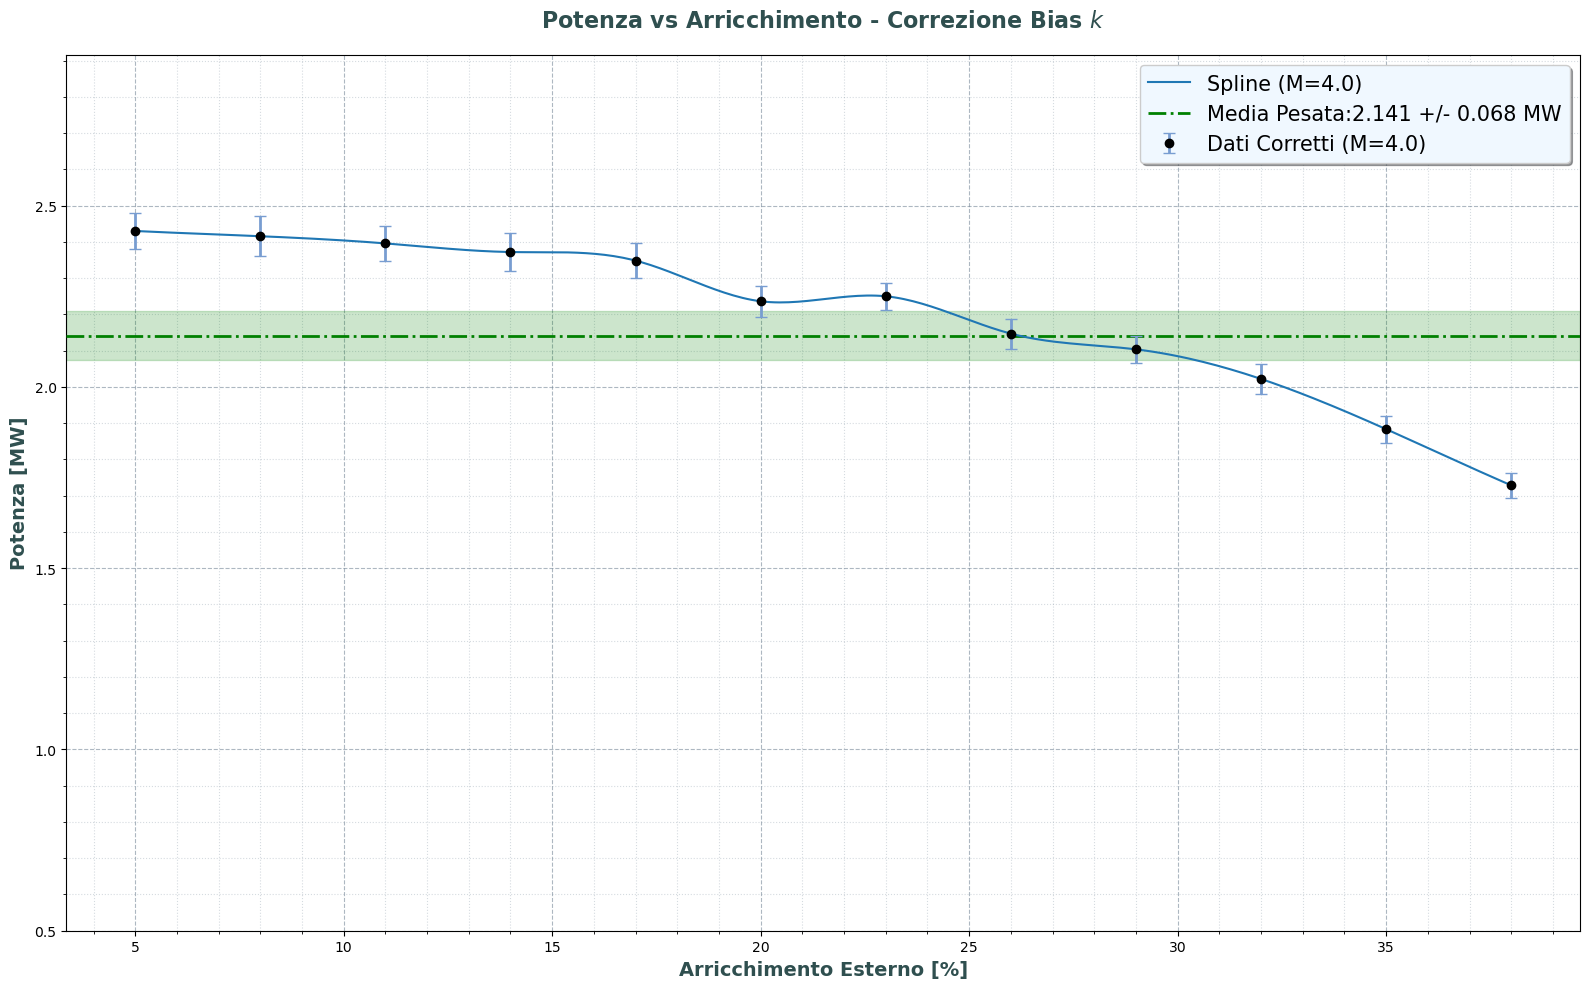

In [15]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import openmc

# Costanti fisiche
E_FISSION_J = 200.0 * 1e6 * 1.6022e-19  # Energia media per fissione [J]
S_INTENSITY = 2.02e17                    # Fotoni/s dal sincrotrone

def parse_result_final(filename):
    """Parsa il file result_final.txt per ottenere i parametri di k."""
    data = []
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith('-') or line.startswith('=') or 'Pres [Atm]' in line:
                continue
            cols = line.split()
            if len(cols) == 12:
                try:
                    data.append(list(map(float, cols)))
                except ValueError:
                    continue
    columns = ['pressione_atm', 'moltiplicatore', 'perc_water', 'arricch_INT', 'arricch_EXT', 
               't_water', 't_fuel', 'k_max', 'std_k_max', 'k_auto', 'std_k_auto', 'compatibilita']
    return pd.DataFrame(data, columns=columns)

def analizza_potenza():
    """Estrae dati, applica correzione del bias k e propaga l'errore."""
    file_list = glob.glob("../fixed/statepoints/statepoint_arr_ext_*.h5")
    df_res = parse_result_final('../result_final.txt')
    
    if not file_list or df_res.empty:
        print("Dati mancanti (statepoints o result_final.txt).")
        return pd.DataFrame()
        
    dati = []
    pattern = re.compile(r"statepoint_arr_ext_(\d+)_pitch_([\d\.]+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        molt = float(match.group(2))
        arr_ext = float(match.group(1)) 
        
        # Matching con result_final.txt (uso isclose per precisione float)
        row = df_res[(np.isclose(df_res['arricch_EXT'], arr_ext)) & 
                     (np.isclose(df_res['moltiplicatore'], molt))]
        
        if row.empty:
            continue
            
        k_sim = row['k_auto'].values[0]
        k_ref = row['k_max'].values[0]
        sigma_k_sim = row['std_k_auto'].values[0]

        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0]
            except KeyError:
                continue
                
        # Calcolo Potenza simulata [MW]
        p_sim = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        err_sim = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        # --- Correzione Bias k ---
        # dP/dk = P / (1-k)
        sensitivita = p_sim / (1 - k_sim)
        
        # Traslazione al valore di riferimento k_max
        p_corr = p_sim + sensitivita * (k_ref - k_sim)
        
        # Propagazione errore stocastico tally + incertezza statistica su k
        err_corr = np.sqrt(err_sim**2 + (sensitivita**2) * (sigma_k_sim**2))
        
        dati.append({
            'Arricchimento': arr_ext,
            'Moltiplicatore': molt,
            'Potenza_MW': p_corr,
            'Errore_MW': err_corr
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    """Visualizzazione con stile unificato e correzione bias."""
    if df.empty:
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    moltiplicatori = df['Moltiplicatore'].unique()
    
    for m in moltiplicatori:
        df_m = df[df['Moltiplicatore'] == m].sort_values(by='Arricchimento')
        x = df_m['Arricchimento'].values
        y = df_m['Potenza_MW'].values
        y_err = df_m['Errore_MW'].values
        
        ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                    elinewidth=2, capsize=4, zorder=5, label=f'Dati Corretti (M={m})')
        
        if len(x) >= 3:
            x_smooth = np.linspace(x.min(), x.max(), 300)
            spline = make_interp_spline(x, y, k=3)
            y_smooth = spline(x_smooth)
            ax.plot(x_smooth, y_smooth, zorder=4, label=f'Spline (M={m})')
        else:
            ax.plot(x, y, zorder=4)

    # Analisi statistica globale
    pesi = 1.0 / (df['Errore_MW']**2)
    media_pesata = np.sum(df['Potenza_MW'] * pesi) / np.sum(pesi)
    errore_media = 1.0 / np.sqrt(np.sum(pesi))
    chi_quadro = np.sum(((df['Potenza_MW'] - media_pesata)**2) / (df['Errore_MW']**2))
    chi_ridotto = chi_quadro / (len(df) - 1)

    errore_media = errore_media * np.sqrt(max(1, chi_ridotto))
    
    ax.axhline(y=media_pesata, color='green', linestyle='-.', linewidth=2, 
               zorder=3, label=f'Media Pesata:{media_pesata:.3f} +/- {errore_media:.3f} MW')
    ax.axhspan(ymin=media_pesata - errore_media, ymax=media_pesata + errore_media, 
               color='green', alpha=0.2, zorder=2)
            
    ax.set_title('Potenza vs Arricchimento - Correzione Bias $k$ ', 
                 fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento Esterno [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=15, facecolor='#F0F8FF')

    plt.ylim(0.5, df['Potenza_MW'].max() * 1.2)
    plt.tight_layout()
    plt.show()

# Esecuzione
df_potenza = analizza_potenza()
plot_scatter_smooth_err(df_potenza)

Dato che la differenza per ogni singola configurazione è nota, in statistica questo non è un errore casuale ma un bias sistematico. È fisicamente più corretto traslare il valore di $P$ per portarlo al target di $k_{ref}$, invece di gonfiare artificialmente le barre di errore.Correggi l'ordinata con l'espansione di Taylor:$$P_{corr} \approx P_{sim} + \frac{P_{sim}}{1-k_{sim}} (k_{ref} - k_{sim})$$A questo punto, nella barra d'errore propaghi unicamente la reale incertezza stocastica sul $k$ stimato dal calcolo di criticità ($\sigma_{k_{sim}}$):$$\sigma_{y_{corr}} = \sqrt{\sigma_{tally}^2 + \left( \frac{P_{sim}}{1-k_{sim}} \right)^2 \sigma_{k_{sim}}^2}$$L'approssimazione al primo ordine regge benissimo dato che parliamo di perturbazioni dell'ordine di $10^{-3}$ (100 pcm).
